# 全连接神经网络训练流程

这份 notebook 展示的是多层感知机 MLP 的完整训练过程。它适合建立一个很重要的整体认识：深度学习不只是“定义模型”，而是“数据、模型、损失、优化、评估、训练策略”共同组成的系统。

## MLP 的核心结构
- 输入层接收特征。
- 若干隐藏层做线性变换 + 非线性激活。
- 输出层给出最终类别分数或预测值。

如果没有激活函数，多层线性层叠起来仍然等价于一层线性变换，所以“非线性”是网络表达能力的关键。


In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize
from matplotlib import pyplot as plt
from tqdm import tqdm
from torch import nn


import torch
import numpy as np
import pandas as pd
import os

plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. 为什么用 FashionMNIST 训练 DNN

虽然图像任务更常见的是 CNN，但用 FashionMNIST 训练 MLP 很适合教学，因为它能清楚展示“先展平，再做全连接”的流程，也能直观看到全连接网络在图像任务上的局限。


In [3]:
train_ds = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

val_ds = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

mean = train_ds.data.float().mean() / 255
std = train_ds.data.float().std() / 255

# 定义一个简单的归一化层
transforms = nn.Sequential(
    Normalize(mean, std)
)

## 2. 多层感知机是怎么工作的

每一层都在做两件事：
- 线性变换：提取新的特征组合。
- 激活函数：引入非线性。

如果把网络看成逐层加工信息，那么越靠后的层，通常越偏向任务相关的抽象表示。


In [4]:
class NeuralNetwork(nn.Module):
    def __init__(self, layers_num=3, transforms=None, activate=nn.ReLU(), dropout=0):
        super(NeuralNetwork, self).__init__()
        self.transform = transforms
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential()

        self.layers.add_module('input', nn.Linear(28 * 28, 64))

        # 批归一化层的引入可以帮助模型在训练过程中更快地收敛，并且在一定程度上减少对初始权重的敏感性，从而提高模型的稳定性和性能。
        self.layers.add_module('batchnorm_0', nn.BatchNorm1d(64))
        self.layers.add_module('relu_0', activate)
        if dropout > 0:
            self.layers.add_module('dropout_0', nn.Dropout(dropout))

        for i in range(1, layers_num):
            self.layers.add_module(f'linear_{i}', nn.Linear(64, 64))
            self.layers.add_module(f'batchnorm_{i}', nn.BatchNorm1d(64))
            self.layers.add_module(
                f'{activate.__class__.__name__.lower()}_{i}', activate)
            if dropout > 0:
                self.layers.add_module(f'dropout_{i}', nn.Dropout(dropout))

        self.layers.add_module('output', nn.Linear(64, 10))
        self.init_weights()

    def init_weights(self):
        for m in self.layers:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.transform(x) if self.transform else x
        x = self.flatten(x)
        logits = self.layers(x)
        return logits


param_total = 0
for idx, (key, value) in enumerate(NeuralNetwork(5, transforms, activate=nn.ReLU(), dropout=0.3).named_parameters()):
    print(f'{idx}: {key} - {value.shape}')
    param_total += value.numel()
print('模型参数总量:', param_total)

0: layers.input.weight - torch.Size([64, 784])
1: layers.input.bias - torch.Size([64])
2: layers.batchnorm_0.weight - torch.Size([64])
3: layers.batchnorm_0.bias - torch.Size([64])
4: layers.linear_1.weight - torch.Size([64, 64])
5: layers.linear_1.bias - torch.Size([64])
6: layers.batchnorm_1.weight - torch.Size([64])
7: layers.batchnorm_1.bias - torch.Size([64])
8: layers.linear_2.weight - torch.Size([64, 64])
9: layers.linear_2.bias - torch.Size([64])
10: layers.batchnorm_2.weight - torch.Size([64])
11: layers.batchnorm_2.bias - torch.Size([64])
12: layers.linear_3.weight - torch.Size([64, 64])
13: layers.linear_3.bias - torch.Size([64])
14: layers.batchnorm_3.weight - torch.Size([64])
15: layers.batchnorm_3.bias - torch.Size([64])
16: layers.linear_4.weight - torch.Size([64, 64])
17: layers.linear_4.bias - torch.Size([64])
18: layers.batchnorm_4.weight - torch.Size([64])
19: layers.batchnorm_4.bias - torch.Size([64])
20: layers.output.weight - torch.Size([10, 64])
21: layers.output

## 3. 评估函数为什么要和训练分开

训练阶段需要梯度，评估阶段只关心结果，所以这里使用 `@torch.no_grad()` 来关闭梯度记录。这样做能：
- 节省显存。
- 提高推理速度。
- 避免把评估过程误接进训练图。


In [42]:
@torch.no_grad()  # 在评估模型时，我们不需要计算梯度，因此使用@torch.no_grad()装饰器来禁用梯度计算，以节省内存和加速计算。
def evaluate(model, dataloader, loss_fn):
    loss_list = []  # 存储每个批次的损失值
    pred_list = []  # 存储每个批次的预测标签
    label_list = []  # 存储每个批次的实际标签

    for data, label in dataloader:
        data = data.to(device)  # 将输入数据移动到指定设备（CPU或GPU）
        label = label.to(device)  # 将标签移动到指定设备（CPU或GPU）

        logits = model(data)  # 将输入数据传递给模型，得到输出的logits
        loss = loss_fn(logits, label)  # 计算当前批次的损失值

        # item()方法将单元素张量转换为Python数值，方便存储和计算。
        loss_list.append(loss.item())  # 将当前批次的损失值添加到列表中

        # 获取模型预测的类别标签, argmax函数返回沿指定维度最大值的索引，这里dim=1表示在类别维度上取最大值的索引，即预测的类别标签
        pred = logits.argmax(dim=1)
        # 将预测标签移动到CPU并转换为NumPy数组，添加到列表中
        pred_list.extend(pred.cpu().numpy().tolist())

        # 将实际标签移动到CPU并转换为NumPy数组，添加到列表中
        label_list.extend(label.cpu().numpy().tolist())

    # 计算整体的准确率，使用sklearn的accuracy_score函数比较预测标签和实际标签
    accuracy = accuracy_score(pred_list, label_list)

    # 返回平均损失值和准确率
    return np.mean(loss_list), accuracy

## 4. 早停与 checkpoint 解决什么问题

训练轮数不是越多越好。继续训练可能让训练集更好，但验证集变差，这就是过拟合。

所以这里加入两种常见保护机制：
- Early Stopping：验证指标长期不提升就停止。
- Checkpoint：及时保存当前最好模型，防止后面训练变差。


In [43]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = -1
        self.wait = 0

    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric
            self.wait = 0
        else:
            self.wait += 1
        return self.wait >= self.patience

In [44]:
class CheckpointsCallback:
    def __init__(self, save_path, save_step=100, model_name="model", save_best_only=True):
        self.save_step = save_step
        self.save_path = save_path
        self.model_name = model_name
        self.save_best_only = save_best_only
        self.best_metric = -1

        if not os.path.exists(save_path):
            os.makedirs(save_path)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return
        if self.save_best_only:
            assert metric is not None, "metric must be provided when save_best_only is True"
            if metric >= self.best_metric:
                self.best_metric = metric
                torch.save(state_dict, os.path.join(
                    self.save_path, f'best_{self.model_name}.ckpt'))
        else:
            torch.save(state_dict, os.path.join(
                self.save_path, f'{self.model_name}_step_{step}.ckpt'))

## 5. 训练循环的核心顺序

几乎所有 PyTorch 训练循环都绕不开这四步：
1. 前向传播得到输出。
2. 计算损失。
3. 反向传播求梯度。
4. 优化器更新参数。

把这四步吃透，比背任何一个具体 API 都更重要。


In [53]:
def train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=20,
    eval_interval=500,
    checkpoints_callback=None,
    earlystop_callback=None,
    tensorboard_callback=None
):

    record_dict = {
        'train': [],
        'val': []
    }

    global_step = 0  # 定义一个全局步骤计数器，用于跟踪训练过程中的总步骤数
    model.train()  # 将模型设置为训练模式，启用dropout和batch normalization等训练特定的行为

    with tqdm(total=epochs * len(train_loader), desc="Training") as pbar:  # 使用tqdm库创建一个进度条，显示训练的进度
        for epoch in range(epochs):  # 训练指定的轮数
            for data, label in train_loader:
                data = data.to(device)  # 将输入数据移动到指定设备（CPU或GPU）
                label = label.to(device)  # 将标签移动到指定设备（CPU或GPU）

                optimizer.zero_grad()  # 梯度清零，准备进行反向传播

                logits = model(data)  # 前向传播，计算模型的输出logits

                loss = loss_fn(logits, label)  # 计算损失值，比较模型的输出logits与实际标签

                loss.backward()  # 反向传播，计算梯度

                optimizer.step()  # 更新模型参数，使用计算得到的梯度

                pred = logits.argmax(dim=1)  # 获取模型预测的类别标签

                # 计算当前批次的准确率
                acc = accuracy_score(pred.cpu().numpy(), label.cpu().numpy())

                loss = loss.item()  # 将损失值从张量转换为Python数值

                # 记录当前批次的损失值和准确率
                record_dict['train'].append({
                    'step': global_step,
                    'loss': loss,
                    'accuracy': acc
                })

                # 每隔eval_interval步进行一次评估，计算验证集上的损失值和准确率，并记录下来
                if global_step % eval_interval == 0:
                    model.eval()  # 将模型设置为评估模式，禁用dropout和batch normalization等训练特定的行为
                    val_loss, val_acc = evaluate(
                        model, val_loader, loss_fn)  # 在验证集上评估模型，得到损失值和准确率
                    record_dict['val'].append({
                        'step': global_step,
                        'loss': val_loss,
                        'accuracy': val_acc
                    })
                    model.train()  # 将模型切换回训练模式，继续训练

                    # 调用回调函数
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"],  # 取出当前学习率
                        )
                    if checkpoints_callback is not None:
                        checkpoints_callback(
                            step=global_step,
                            state_dict=model.state_dict(),
                            metric=val_acc
                        )
                    if earlystop_callback is not None and earlystop_callback(val_acc):
                        print(
                            f"Early stop at epoch {epoch} / step {global_step}, val_acc: {val_acc:.4f}")
                        return record_dict

                global_step += 1  # 更新全局步骤计数器
                pbar.update(1)  # 更新进度条
                pbar.set_postfix({'epoch': epoch})  # 在进度条上显示当前的epoch信息

    return record_dict

## 6. 激活函数和 Dropout 的实验意义

后面的几组实验不是简单“换个参数试试”，而是在比较网络设计选择的影响：
- ReLU 和 SELU 改变非线性形状。
- Dropout 通过随机失活神经元来抑制过拟合。

学习时建议对比：训练速度、验证准确率、是否更稳定。


Training:  55%|█████▌    | 2600/4700 [00:50<00:40, 51.72it/s, epoch=11]

Early stop at epoch 11 / step 2600, val_acc: 0.8510


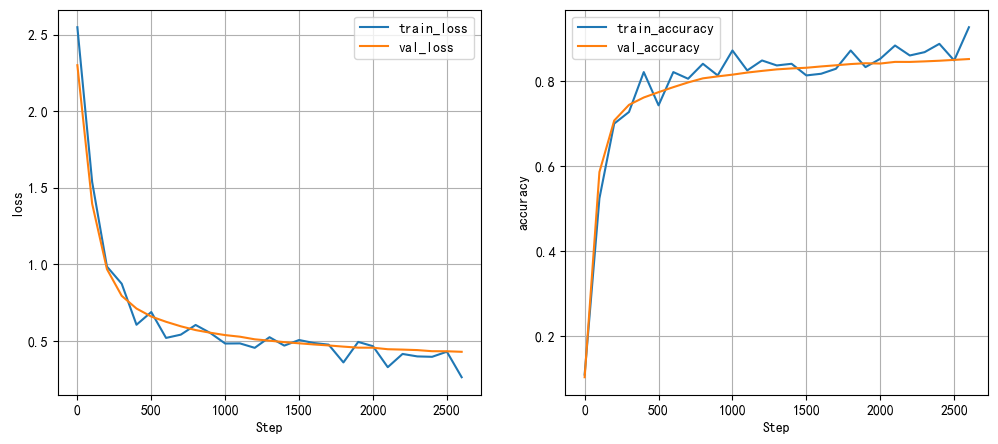

In [54]:
# 10层的神经网络模型，包含输入层、10个隐藏层和输出层，每个隐藏层包含64个神经元，并且在每个隐藏层后面都添加了批归一化层和ReLU激活函数。
model = NeuralNetwork(10, transforms).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
earlystopper = EarlyStopCallback(patience=5, min_delta=0.01)
checkpinter = CheckpointsCallback(
    save_path="./checkpoints", model_name="dnn", save_step=100, save_best_only=True)

record_dict = train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=20, eval_interval=100,
    earlystop_callback=earlystopper,
    checkpoints_callback=checkpinter
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx, item in enumerate(['loss', 'accuracy']):
    ax = axs[idx]
    ax.plot([x['step'] for x in record_dict['train'][::100]],
            [x[item] for x in record_dict['train'][::100]], label='train_' + item)
    ax.plot([x['step'] for x in record_dict['val']],
            [x[item] for x in record_dict['val']], label='val_' + item)
    ax.set_xlabel('Step')
    ax.set_ylabel(item)
    ax.grid()
    ax.legend()

Training:  38%|███▊      | 1800/4700 [00:39<01:03, 45.94it/s, epoch=7]

Early stop at epoch 7 / step 1800, val_acc: 0.8504


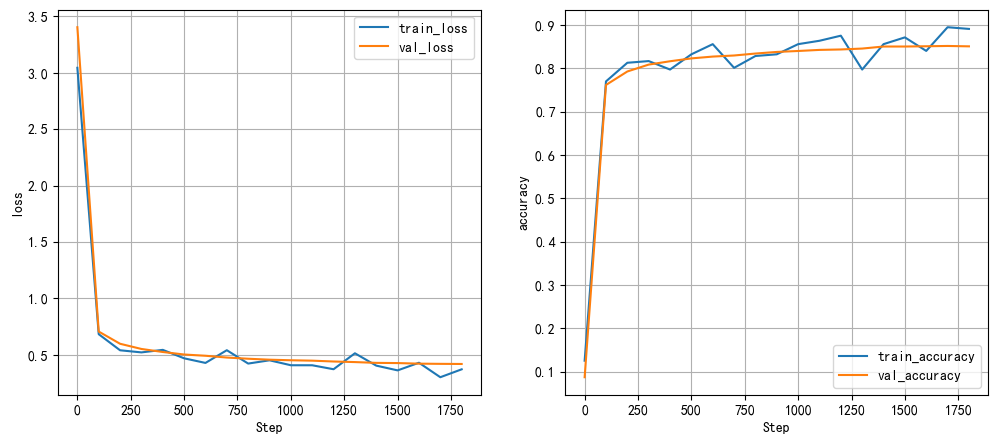

In [57]:
# 修改激活函数为SELU，其他部分保持不变。
model = NeuralNetwork(10, transforms, activate=nn.SELU()).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
earlystopper = EarlyStopCallback(patience=5, min_delta=0.01)
checkpinter = CheckpointsCallback(
    save_path="./checkpoints", model_name="dnn", save_step=100, save_best_only=True)

record_dict = train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=20, eval_interval=100,
    earlystop_callback=earlystopper,
    checkpoints_callback=checkpinter
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx, item in enumerate(['loss', 'accuracy']):
    ax = axs[idx]
    ax.plot([x['step'] for x in record_dict['train'][::100]],
            [x[item] for x in record_dict['train'][::100]], label='train_' + item)
    ax.plot([x['step'] for x in record_dict['val']],
            [x[item] for x in record_dict['val']], label='val_' + item)
    ax.set_xlabel('Step')
    ax.set_ylabel(item)
    ax.grid()
    ax.legend()

Training:  60%|█████▉    | 2800/4700 [00:54<00:36, 51.54it/s, epoch=11]

Early stop at epoch 11 / step 2800, val_acc: 0.7865


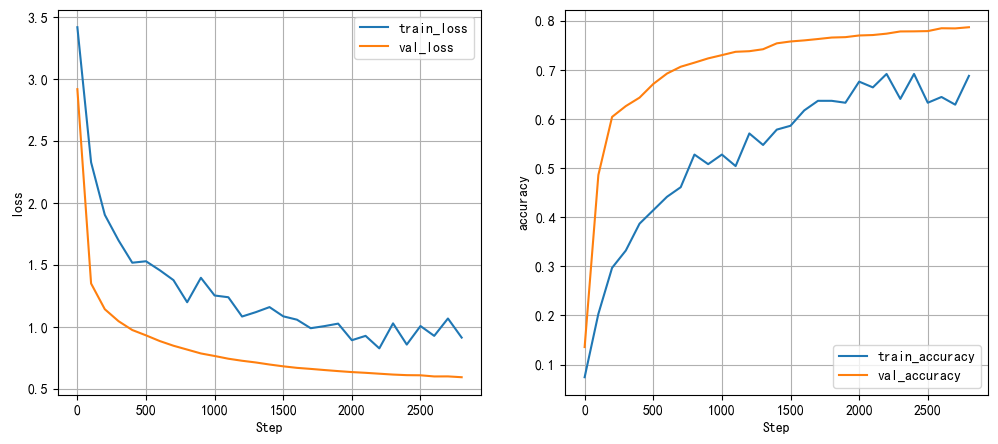

In [59]:
# 在SELU激活函数的基础上添加Dropout层，dropout的概率设置为0.3。
model = NeuralNetwork(
    10, transforms, activate=nn.SELU(), dropout=0.3
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
earlystopper = EarlyStopCallback(patience=5, min_delta=0.01)
checkpinter = CheckpointsCallback(
    save_path="./checkpoints", model_name="dnn", save_step=100, save_best_only=True)

record_dict = train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=20, eval_interval=100,
    earlystop_callback=earlystopper,
    checkpoints_callback=checkpinter
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx, item in enumerate(['loss', 'accuracy']):
    ax = axs[idx]
    ax.plot([x['step'] for x in record_dict['train'][::100]],
            [x[item] for x in record_dict['train'][::100]], label='train_' + item)
    ax.plot([x['step'] for x in record_dict['val']],
            [x[item] for x in record_dict['val']], label='val_' + item)
    ax.set_xlabel('Step')
    ax.set_ylabel(item)
    ax.grid()
    ax.legend()